In [ ]:

library(tidyverse)
library(readr)
library(lubridate)

options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 150)

holdout_weeks <- 104  # adjust as desired (e.g. 52 or 104)
season_lag_weeks <- 104 # approx. 2 years (52*2). Adjust if you prefer a date-based join


ilinet <- readr::read_rds('data/fluview_clean/ilinet_clean.rds')

In [78]:
print_function <- function(rmse_in_sample, rmse_holdout, model_name){
    cat(paste0(model_name, " RMSE - In Sample: ", round(rmse_in_sample, 4), " | Holdout: ", round(rmse_holdout, 4), "\n"))
}

In [79]:
# First we need to remove or NA values form the data set
df <- ilinet %>%
    filter(region_type == "National") %>%
    arrange(week_start) %>%
    arrange(week_start) %>%
  select(week_start, percent_weighted_ili) %>%
  mutate(week_start = as.Date(week_start))

ts_ili = ts(data = df$percent_weighted_ili, start = c(year(min(df$week_start)), month(min(df$week_start))), frequency = 52) 
#   plot(main = "National ILI Percentage Over Time", xlab = "Time", ylab = "Percent Weighted ILI")

ts_train = ts(ts_ili[1:(length(ts_ili)-holdout_weeks)], start = start(ts_ili), frequency = frequency(ts_ili))
ts_holdout = ts(ts_ili[(length(ts_ili)-holdout_weeks+1):length(ts_ili)], start = end(ts_train) + c(0,1), frequency = frequency(ts_ili))

train = ts_ili[1:(length(ts_ili)-holdout_weeks)]
holdout = ts_ili[(length(ts_ili)-holdout_weeks+1):length(ts_ili)]

calculate_rmse <- function(train, holdout,predict_func) {
  n <- length(train)
  mse<-0
  fc<-predict_func(train)
  yt<-holdout[1]
  fc_error<-yt-fc
  mse<-mse+fc_error^2
  for (i in 2:length(holdout)) {
    fc<-predict_func(c(train, holdout[1:(i-1)]))
    yt<-holdout[i]
    fc_error<-yt-fc
    mse<-mse+fc_error^2
  }
  mse<-mse/length(holdout)
  return(sqrt(mse))
}
persistence_predict <- function(train){
    return (train[length(train)])
}
# surely we can write an MSE function to just evaluate this for any model since the predict is based on the observed data.
# as it is rolling 1 step forcast

rmse_out_sample <- calculate_rmse(train,holdout,persistence_predict)

# how do we use this to calculate the in-sample error? we can just use the same function but with the train data as the holdout and a smaller train set.
rmse_in_sample <- calculate_rmse(c(train[1]),train[2:length(train)],persistence_predict)

print_function(rmse_in_sample, rmse_out_sample, "Persistence")

Persistence RMSE - In Sample: 0.3895 | Holdout: 0.5334


In [80]:
average_predict <- function(train){
    return (mean(train))
}
rmse_out_sample <- calculate_rmse(train,holdout,average_predict)
rmse_in_sample <- calculate_rmse(c(train[1]),train[2:length(train)],average_predict)
print_function(rmse_in_sample, rmse_out_sample, "Average")

Average RMSE - In Sample: 1.4531 | Holdout: 2.002


In [81]:
# lastly we will aso just check the final baseline which is IID
weekly_mean<- tapply(ts_train,cycle(ts_train),mean)
holdout_iid <- weekly_mean[cycle(ts_holdout)]
rmse_out_sample <- sqrt(mean((ts_holdout-holdout_iid)^2))
rmse_in_sample <- sqrt(mean((ts_train-weekly_mean[cycle(ts_train)])^2))
print_function(rmse_in_sample, rmse_out_sample, "IID")


IID RMSE - In Sample: 1.0352 | Holdout: 1.486


In [83]:
# now we will implement exponential smoothing and see how it performs. We will use the HoltWinters function from the stats package which is a simple implementation of exponential smoothing. We will use the default parameters which are alpha = 0.2, beta = 0.1, and gamma = 0.1. We will also use the forecast function from the forecast package to make predictions.
library(forecast)
# Fit the Holt-Winters model to the training data
# ts_train
fit_HW <- HoltWinters(ts_train, seasonal = "additive")
# 

advanced_rmse_1_step <- function(train,holdout,fit_func){
    sse <- 0
    forecasts <- numeric(length(holdout))
    current_series <- train
    for(i in 1:length(holdout)) {
      fit <- fit_func(current_series)
      forecasts[i] <- predict(fit, n.ahead = 1)
      sse <- sse+ (forecasts[i]-holdout[i])^2
      current_series <- ts(c(current_series, holdout[i]),frequency = frequency(train),start = start(train))
    }
    rmse_os <- sqrt(mean((forecasts-holdout)^2)) # we only care about the out of sample rmse.
    return(rmse_os)
}

# we loook at the insample error by just fitting the model to the whole training data and then calculating the rmse on the training data.

in_sample_forecast <- fitted(fit_HW_full)
rmse_in_sample <- sqrt(mean((in_sample_forecast - ts_train)^2))
HW_add <- function(x) HoltWinters(x, seasonal = "additive")
rmse_out_sample <- advanced_rmse_1_step(ts_train,ts_holdout, HW_add)  

print_function(rmse_in_sample, rmse_out_sample, "Holt-Winters (Additive)")

Holt-Winters (Additive) RMSE - In Sample: 1.8614 | Holdout: 0.4899


In [ ]:
# We cannot use holt winters exponential smoothing with multiplicative values since sometimes we have 0.



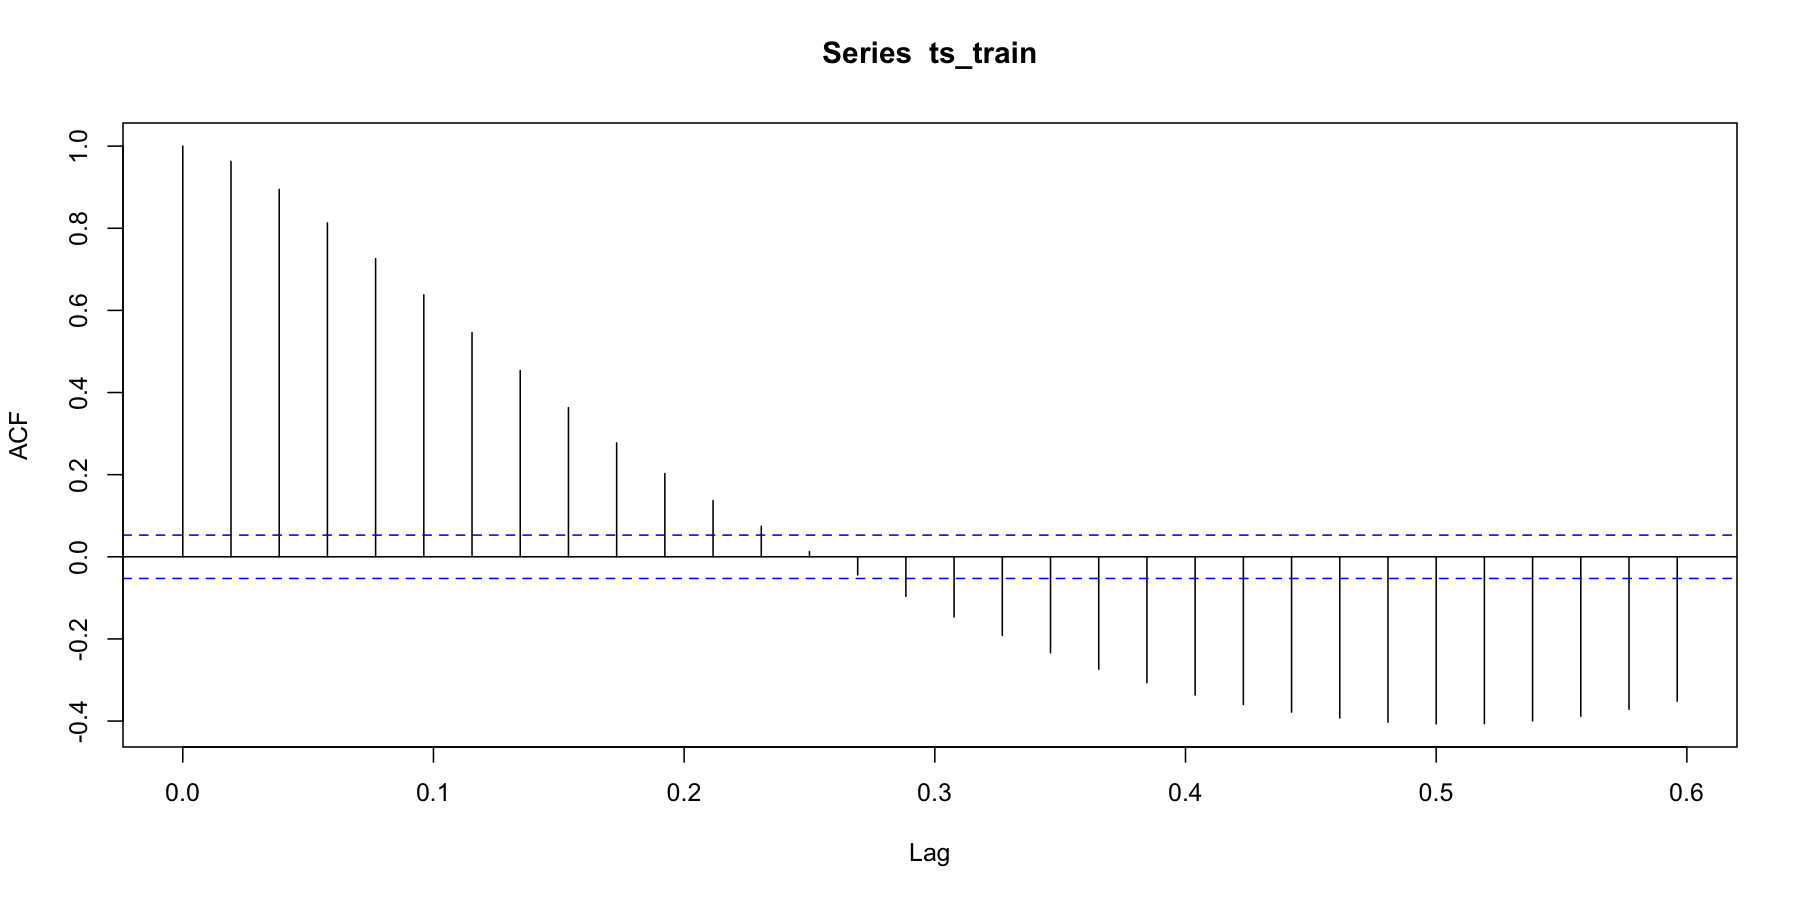

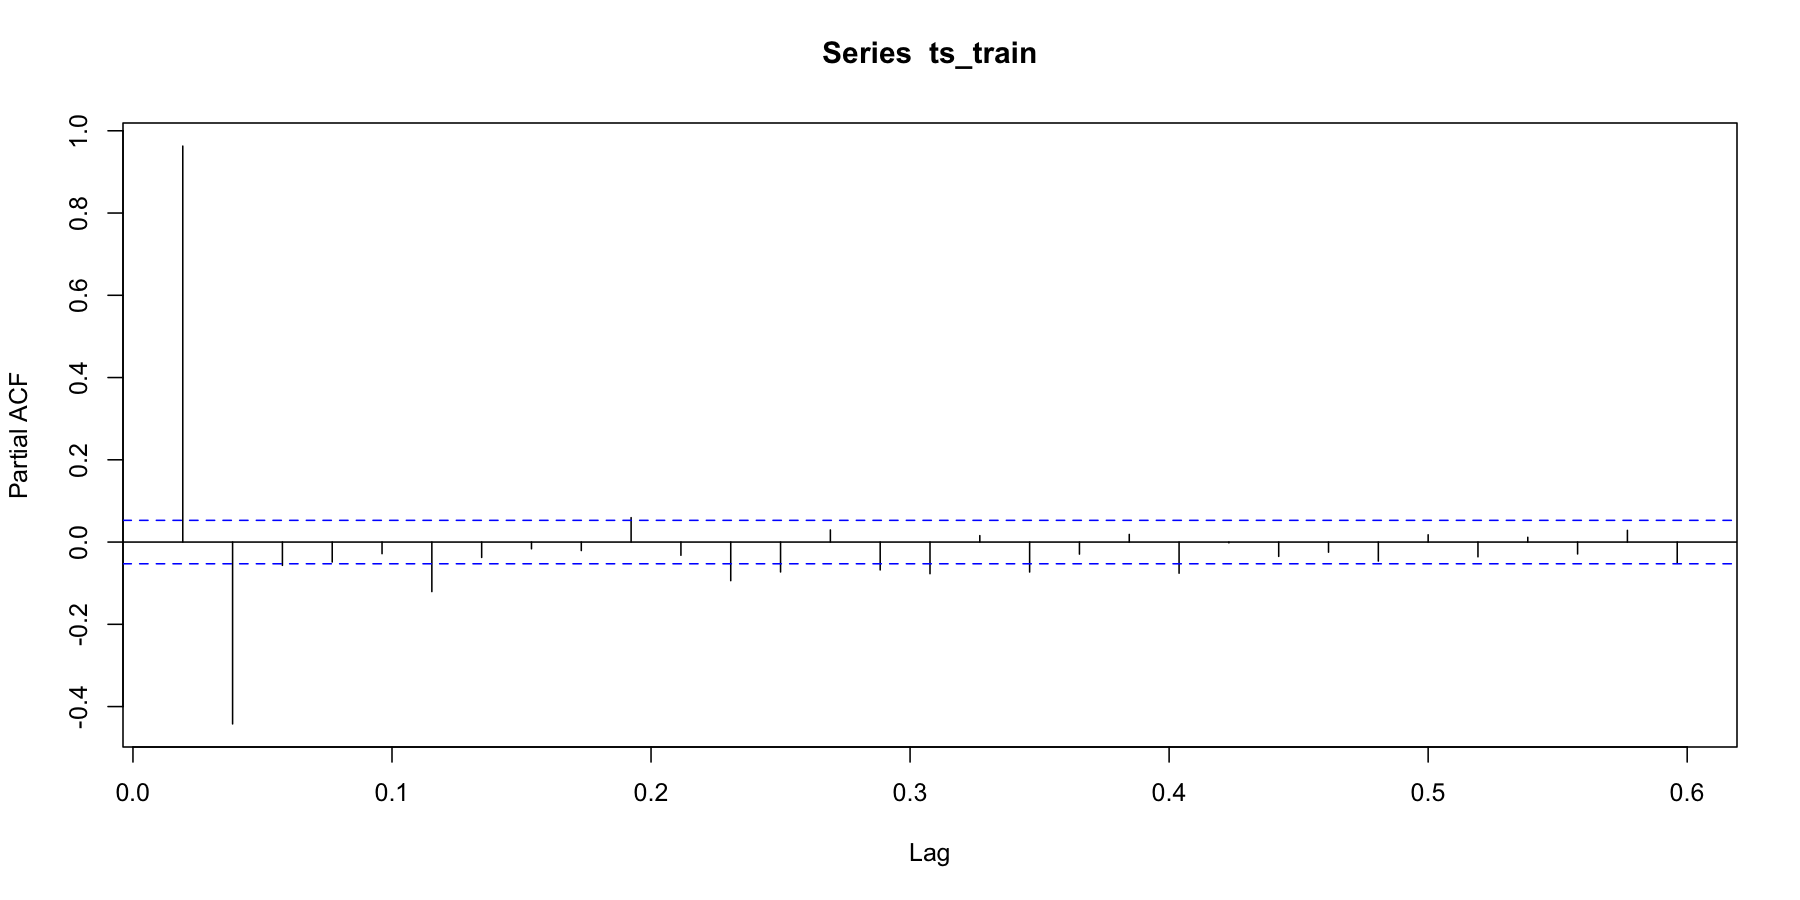

In [75]:
# moving on to arima
acf(ts_train)
pacf(ts_train)
#  we can see a seasonal component and evidence of an AR process.
# noting the acf we see that the series needs differencing to remove the trend and seasonality.


Series: ts_train_diff 
ARIMA(3,0,0)(1,0,0)[52] with non-zero mean 

Coefficients:
         ar1     ar2      ar3    sar1    mean
      0.4005  0.0651  -0.0425  0.3510  0.0024
s.e.  0.0033  0.0117   0.0361  0.0191  0.0234

sigma^2 = 0.1104:  log likelihood = -437.54
AIC=887.08   AICc=887.14   BIC=918.45

Training set error measures:
                       ME      RMSE       MAE MPE MAPE      MASE         ACF1
Training set 0.0002368224 0.3316301 0.1944727 NaN  Inf 0.7502272 -0.005192408

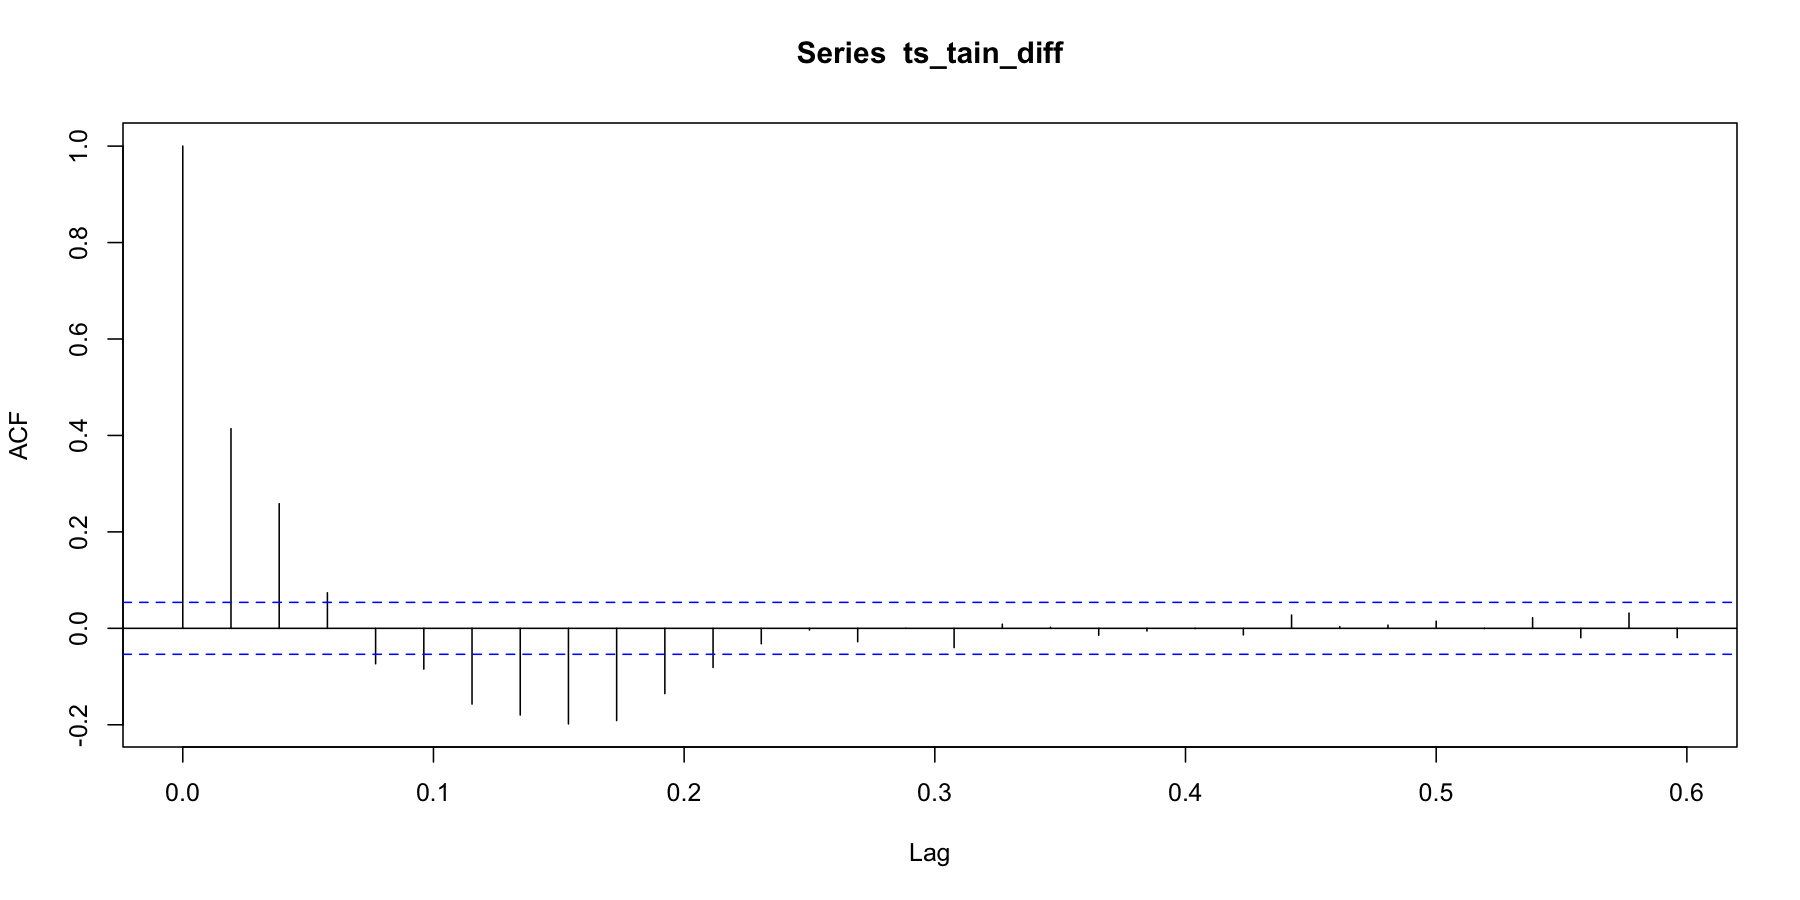

In [76]:
ts_train_diff <- diff(ts_train, differences = 1)

acf(ts_tain_diff)
fit_arima <- auto.arima(ts_train_diff,)

summary(fit_arima)

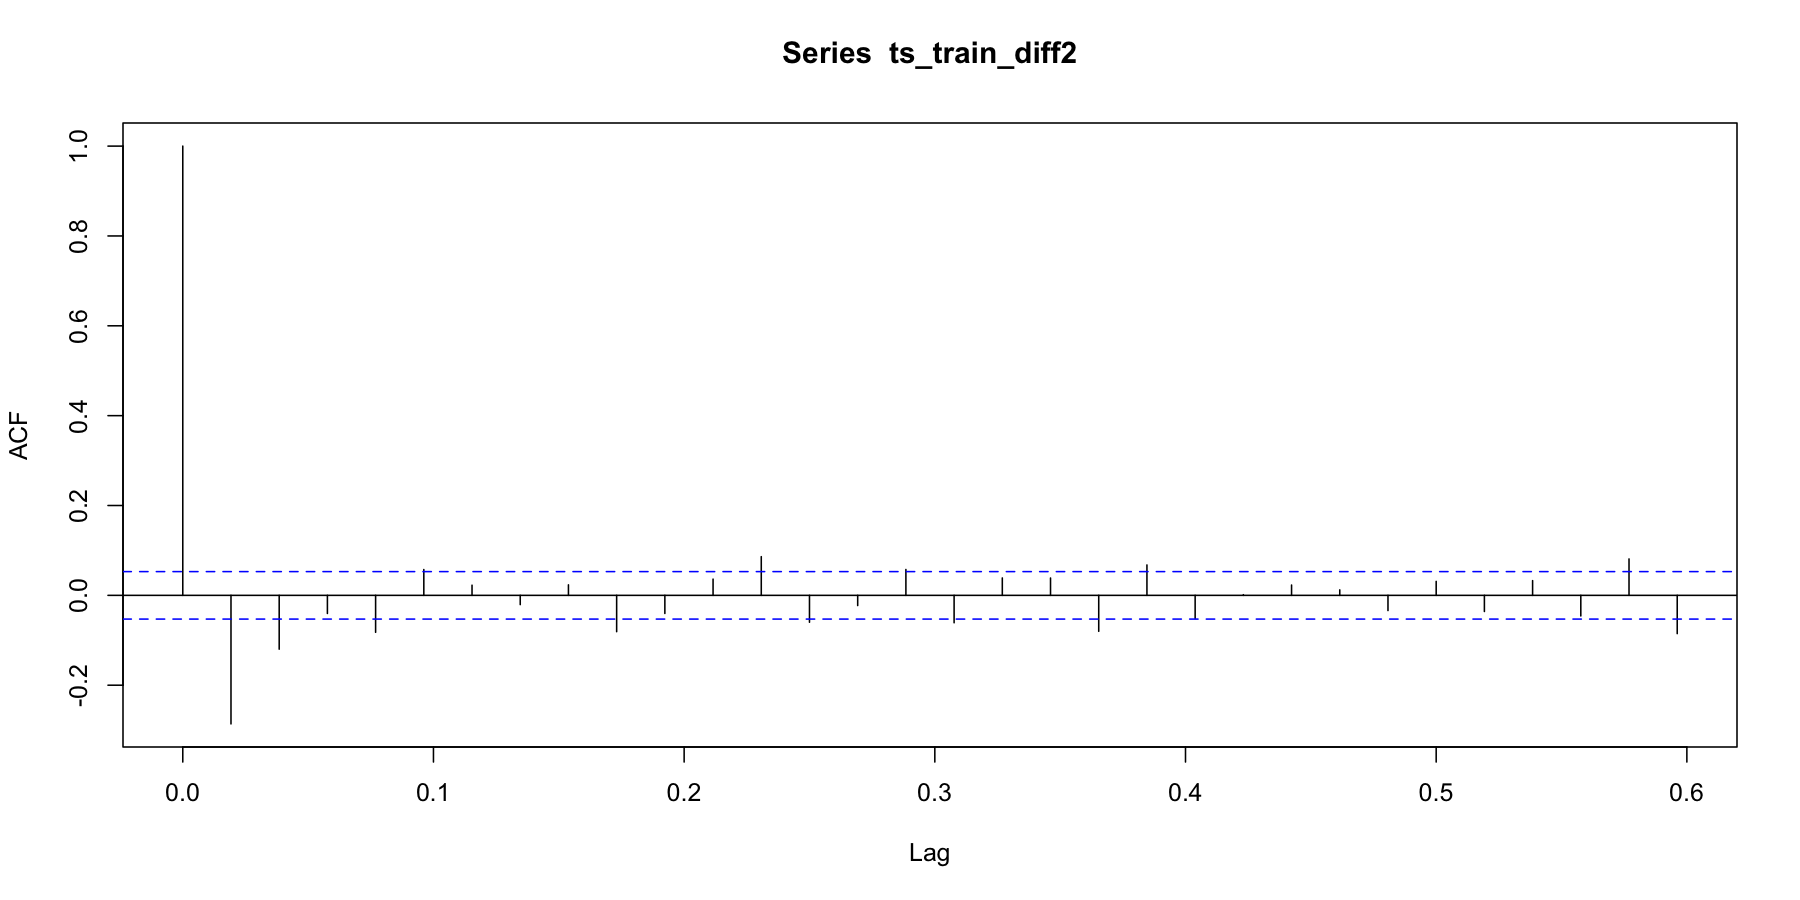

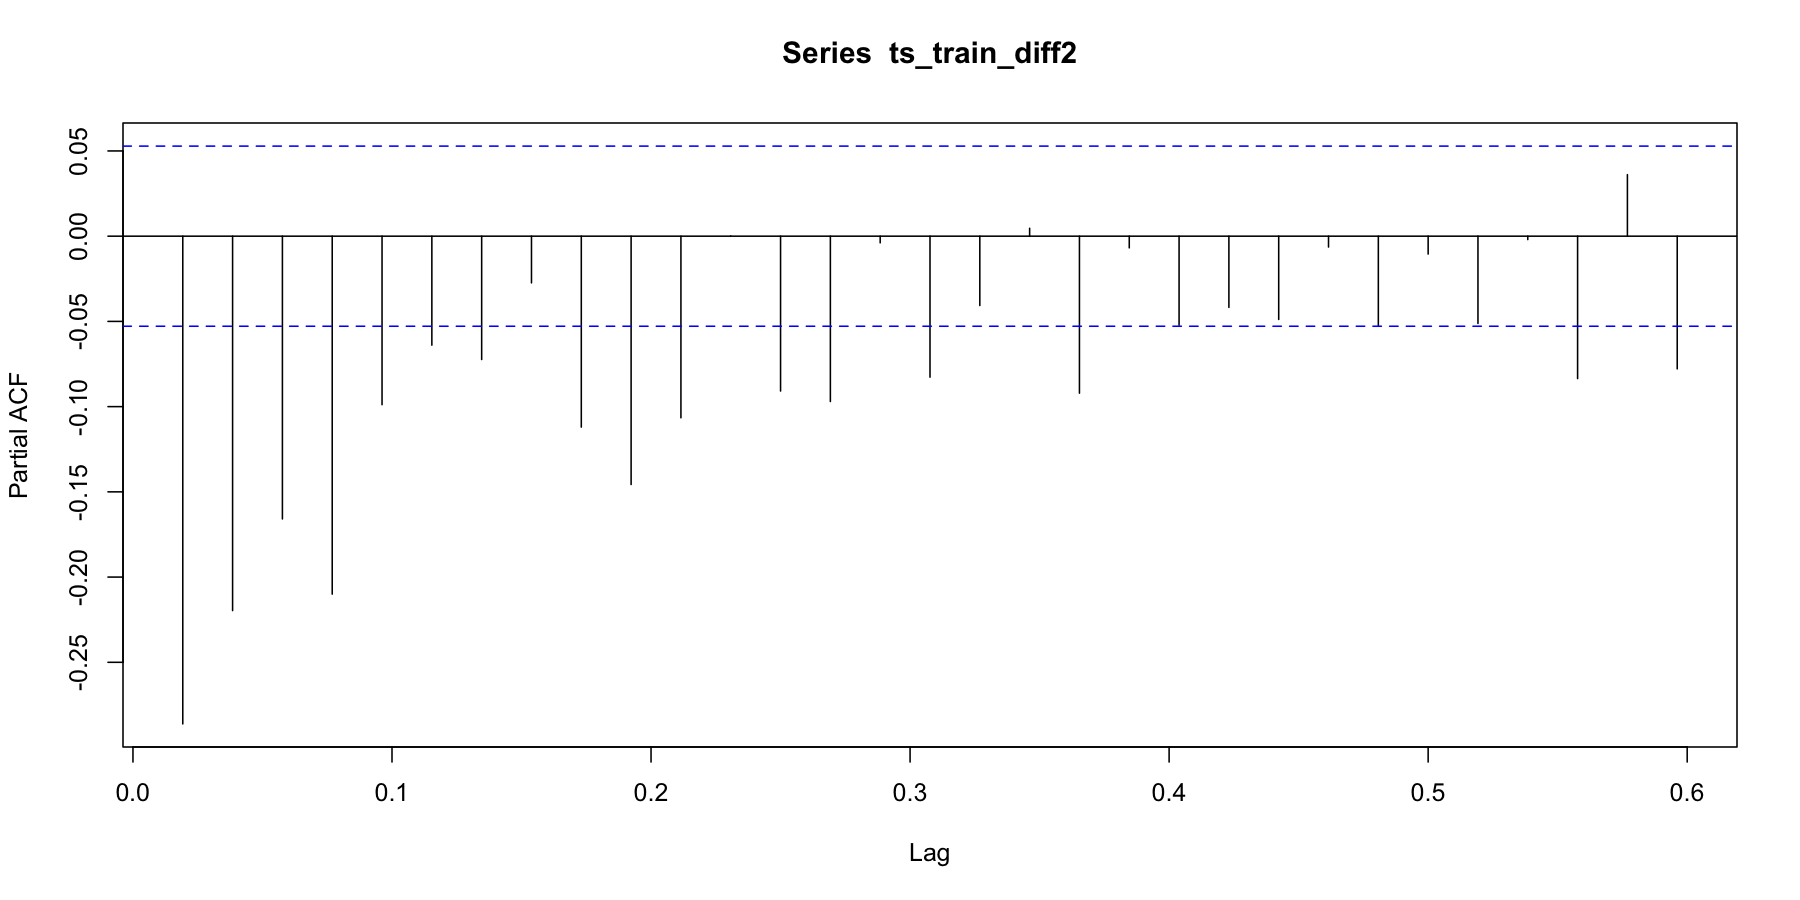

In [ ]:
# now that we do this we will need to calculate the 
ts_train_diff2 = diff(ts_train_diff,lag = 1)
acf(ts_train_diff2)


In [ ]:

arima_fc <- function(ts_train,ts_holdout,order,seasonal = list(order = c(0,0,0), period = 52),method,train_coeff,include.mean,iprint=T){
    {obj = arima(ts)}
    fc <- 
}

In [85]:
ilinet


region_type,region,year,week,percent_weighted_ili,percent_unweighted_ili,age_0_4,age_25_49,age_25_64,age_5_24,age_50_64,age_65,ilitotal,num_of_providers,total_patients,week_start
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<date>
National,NA,1997,40,1.101480,1.216860,179,NA,157,205,NA,29,570,192,46842,1997-09-29
National,NA,1997,41,1.200070,1.280640,199,NA,151,242,NA,23,615,191,48023,1997-10-06
National,NA,1997,42,1.378760,1.239060,228,NA,153,266,NA,34,681,219,54961,1997-10-13
National,NA,1997,43,1.199200,1.144730,188,NA,193,236,NA,36,653,213,57044,1997-10-20
National,NA,1997,44,1.656180,1.261120,217,NA,162,280,NA,41,700,213,55506,1997-10-27
National,NA,1997,45,1.413260,1.282750,178,NA,148,281,NA,48,655,195,51062,1997-11-03
National,NA,1997,46,1.986800,1.445790,294,NA,240,328,NA,70,932,248,64463,1997-11-10
National,NA,1997,47,2.447490,1.647960,288,NA,293,456,NA,63,1100,256,66749,1997-11-17
National,NA,1997,48,1.739010,1.675170,268,NA,206,343,NA,69,886,252,52890,1997-11-24
